<a href="https://colab.research.google.com/github/ibrahim2230/audio-digit-classification/blob/main/EE413_DFT_Part.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##  Frequency-Domain Feature Extraction (DFT-Based Analysis)

This section describes the methods used to analyze audio signals using Digital Signal Processing (DSP) techniques. The goal is to extract meaningful features from speech signals for classification.

---

### 1. Audio Loading and Preprocessing

Each audio file is loaded as a time-domain signal along with its sampling rate.  
The signal is converted to a single channel (if needed) and normalized to ensure consistency across recordings.

---

### 2. Fast Fourier Transform (FFT)

The FFT is used to convert the signal from the time domain to the frequency domain.  
This allows analysis of how the signal’s energy is distributed across different frequencies.

The output consists of:
- Frequency values (Hz)  
- Magnitude spectrum representing the strength of each frequency component  

---

### 3. Spectral Features (DFT-Based)

The following spectral features are extracted:

- **Spectral Centroid**: Represents the “center of mass” of the spectrum  
- **Spectral Bandwidth**: Measures how spread out the frequencies are  
- **Peak Frequency**: Frequency with the highest magnitude  
- **Spectral Energy**: Total energy in the frequency domain  

---

### 4. Band Energy Features

Energy distribution is analyzed across frequency bands:

- Low-frequency energy (0–500 Hz)  
- Mid-frequency energy (500–2000 Hz)  
- High-frequency energy (>2000 Hz)  

These features help capture how energy is distributed in speech signals.

---

### 5. Spectral Rolloff

Spectral rolloff is the frequency below which a certain percentage (typically 85%) of the total energy is contained.  
It indicates where most of the signal energy is concentrated.

---

### 6. Spectral Leakage and Windowing

Spectral leakage occurs when the signal is not perfectly periodic within the analysis window, causing energy to spread across frequencies.  
Applying windowing functions (e.g., Hamming window) reduces leakage and produces a cleaner spectrum.

---

### 7. Frequency Resolution and Zero-Padding

Frequency resolution depends on the signal length.  
Longer signals provide higher resolution and sharper spectral peaks.

Zero-padding increases the number of FFT points, producing a smoother spectrum but does not add new information.

---

### 8. MFCC Features

Mel-Frequency Cepstral Coefficients (MFCCs) capture perceptually relevant features of speech.  
They represent how humans perceive sound and are widely used in audio classification tasks.

---

### 9. Formant Frequencies (LPC-Based)

Formant frequencies represent resonant frequencies of the vocal tract.  
They are estimated using Linear Predictive Coding (LPC), which provides a more accurate representation than simple peak detection.

---

### 10. Harmonic-to-Noise Ratio (HNR)

HNR measures the ratio of harmonic (periodic) components to noise in the signal.

- Higher HNR → cleaner, more periodic signal  
- Lower HNR → noisier signal  





In [20]:
!pip install librosa

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

In [22]:
def load_audio(file_path):
    sample_rate, signal = wavfile.read(file_path)

    if signal.ndim > 1:
        signal = signal[:, 0]

    signal = signal.astype(float)

    signal = signal / np.max(np.abs(signal))

    return sample_rate, signal

In [23]:
def compute_fft(signal, sample_rate):
    N = len(signal)

    spectrum = np.fft.rfft(signal)
    magnitude = np.abs(spectrum)

    freqs = np.fft.rfftfreq(N, d=1/sample_rate)

    return freqs, magnitude

In [24]:
def plot_spectrum(freqs, magnitude):
    plt.figure(figsize=(10,4))
    plt.plot(freqs, magnitude)
    plt.title("Frequency Spectrum")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.grid()
    plt.show()

In [8]:
!git clone https://github.com/Jakobovski/free-spoken-digit-dataset.git

Cloning into 'free-spoken-digit-dataset'...
remote: Enumerating objects: 4260, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 4260 (delta 25), reused 8 (delta 8), pack-reused 4212 (from 1)
Receiving objects: 100% (4260/4260), 30.38 MiB | 21.04 MiB/s, done.
Resolving deltas: 100% (129/129), done.


In [25]:
file_path = "free-spoken-digit-dataset/recordings/0_george_0.wav"

Sample rate: 8000
Signal length: 2384


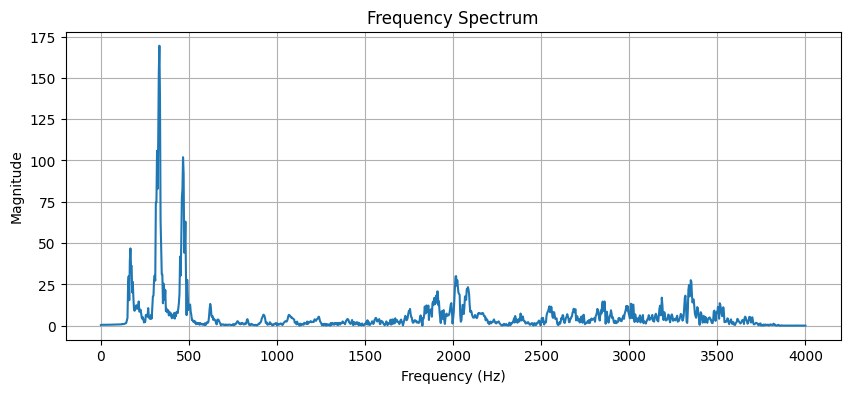

In [26]:
sample_rate, signal = load_audio(file_path)

print("Sample rate:", sample_rate)
print("Signal length:", len(signal))

freqs, magnitude = compute_fft(signal, sample_rate)

plot_spectrum(freqs, magnitude)

In [27]:
def zero_padding_fft_separate(signal, sample_rate):
    N = len(signal)
    N_padded = 4 * N

    # Original FFT
    freqs1 = np.fft.rfftfreq(N, d=1/sample_rate)
    mag1 = np.abs(np.fft.rfft(signal))

    # Zero-padded FFT
    freqs2 = np.fft.rfftfreq(N_padded, d=1/sample_rate)
    mag2 = np.abs(np.fft.rfft(signal, n=N_padded))

    # Plot 1: Original
    plt.figure(figsize=(10,4))
    plt.plot(freqs1, mag1)
    plt.title("Original Spectrum")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.grid()
    plt.show()

    # Plot 2: Zero-padded
    plt.figure(figsize=(10,4))
    plt.plot(freqs2, mag2)
    plt.title("Zero-Padded Spectrum")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.grid()
    plt.xlim(300, 600)

    plt.show()

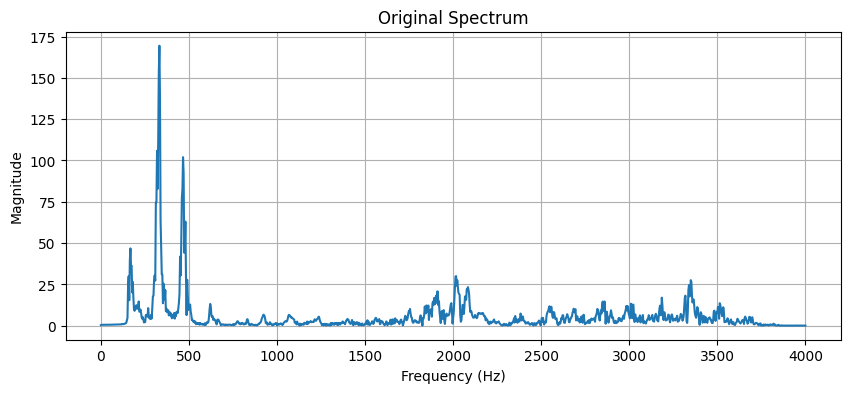

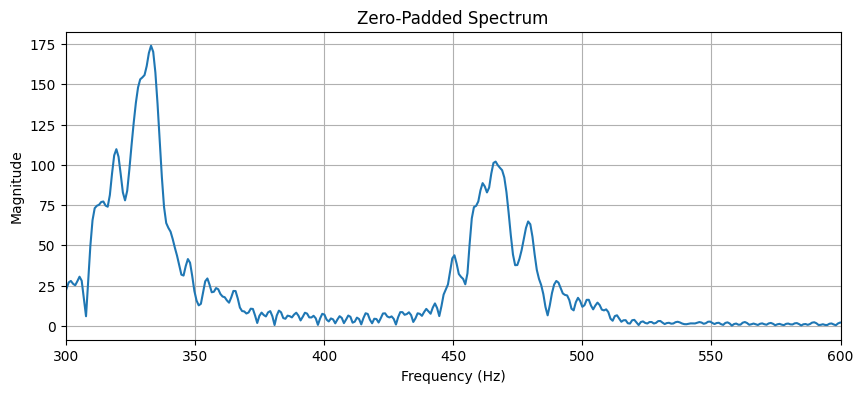

In [28]:
zero_padding_fft_separate(signal, sample_rate)

In [31]:
def compare_frequency_resolution_separate(signal, sample_rate):
    N = len(signal)

    # Short signal (half length)
    short_signal = signal[:N//2]

    # Full signal
    full_signal = signal

    # FFT for short signal
    f_short = np.fft.rfftfreq(len(short_signal), d=1/sample_rate)
    mag_short = np.abs(np.fft.rfft(short_signal))

    # FFT for full signal
    f_full = np.fft.rfftfreq(len(full_signal), d=1/sample_rate)
    mag_full = np.abs(np.fft.rfft(full_signal))

    # Plot 1: Short signal
    plt.figure(figsize=(10,4))
    plt.plot(f_short, mag_short)
    plt.title("Short Signal (Low Frequency Resolution)")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.grid()
    plt.show()

    # Plot 2: Full signal
    plt.figure(figsize=(10,4))
    plt.plot(f_full, mag_full)
    plt.title("Full Signal (High Frequency Resolution)")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.grid()
    plt.show()

    # Print resolution values
    delta_f_short = sample_rate / len(short_signal)
    delta_f_full = sample_rate / len(full_signal)

    print("Short signal resolution:", delta_f_short)
    print("Full signal resolution:", delta_f_full)

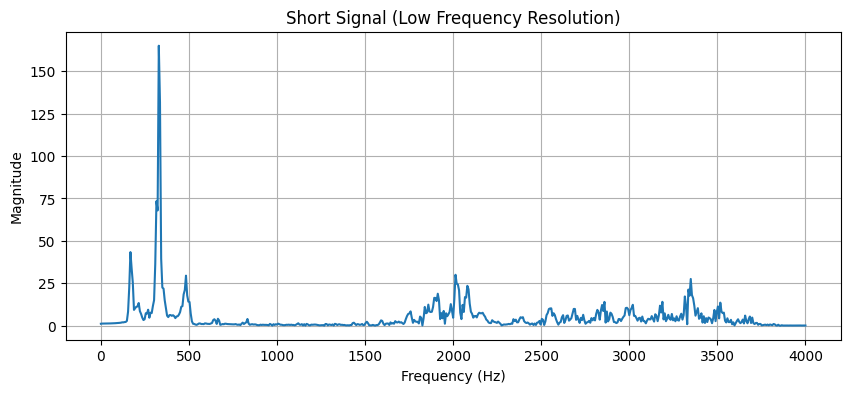

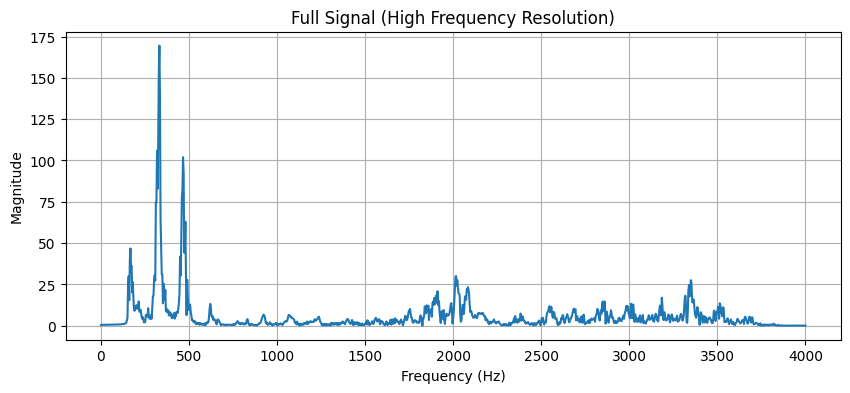

Short signal resolution: 6.7114093959731544
Full signal resolution: 3.3557046979865772


In [32]:
compare_frequency_resolution_separate(signal, sample_rate)

In [33]:
import numpy as np

def spectral_centroid(freqs, magnitude):
    """
    Compute spectral centroid.

    Parameters:
        freqs (np.ndarray): Frequency bins in Hz
        magnitude (np.ndarray): Magnitude spectrum

    Returns:
        float: Spectral centroid in Hz
    """
    if np.sum(magnitude) == 0:
        return 0.0
    return np.sum(freqs * magnitude) / np.sum(magnitude)


def spectral_bandwidth(freqs, magnitude, centroid=None):
    """
    Compute spectral bandwidth.

    Parameters:
        freqs (np.ndarray): Frequency bins in Hz
        magnitude (np.ndarray): Magnitude spectrum
        centroid (float or None): Precomputed centroid

    Returns:
        float: Spectral bandwidth in Hz
    """
    if np.sum(magnitude) == 0:
        return 0.0

    if centroid is None:
        centroid = spectral_centroid(freqs, magnitude)

    return np.sqrt(np.sum(((freqs - centroid) ** 2) * magnitude) / np.sum(magnitude))


def peak_frequency(freqs, magnitude):
    """
    Find the peak frequency.

    Parameters:
        freqs (np.ndarray): Frequency bins in Hz
        magnitude (np.ndarray): Magnitude spectrum

    Returns:
        float: Peak frequency in Hz
    """
    return freqs[np.argmax(magnitude)]

In [34]:
centroid = spectral_centroid(freqs, magnitude)
bandwidth = spectral_bandwidth(freqs, magnitude, centroid)
peak = peak_frequency(freqs, magnitude)

print("Spectral Centroid:", centroid, "Hz")
print("Spectral Bandwidth:", bandwidth, "Hz")
print("Peak Frequency:", peak, "Hz")

Spectral Centroid: 1566.826916535579 Hz
Spectral Bandwidth: 1189.6494089653186 Hz
Peak Frequency: 332.2147651006712 Hz


In [35]:
import os
import pandas as pd

def extract_features_from_all_files(folder_path):
    """
    Extract spectral features from all WAV files in a folder.

    Parameters:
        folder_path (str): Path to folder containing WAV files

    Returns:
        pd.DataFrame: Table of extracted features
    """
    rows = []

    for file_name in sorted(os.listdir(folder_path)):
        if not file_name.endswith(".wav"):
            continue

        file_path = os.path.join(folder_path, file_name)

        # Load audio using your existing function
        sample_rate, signal = load_audio(file_path)

        # Compute FFT using your existing function
        freqs, magnitude = compute_fft(signal, sample_rate)

        # Extract features using your existing functions
        centroid = spectral_centroid(freqs, magnitude)
        bandwidth = spectral_bandwidth(freqs, magnitude, centroid)
        peak = peak_frequency(freqs, magnitude)

        # Label is the first part before underscore, e.g. 0_george_0.wav -> 0
        digit = int(file_name.split("_")[0])

        rows.append({
            "file_name": file_name,
            "digit": digit,
            "sample_rate": sample_rate,
            "signal_length": len(signal),
            "spectral_centroid": centroid,
            "spectral_bandwidth": bandwidth,
            "peak_frequency": peak
        })

    df = pd.DataFrame(rows)
    return df

In [39]:
import os
import pandas as pd
import numpy as np

# -----------------------------
# Existing feature functions
# -----------------------------

def spectral_centroid(freqs, magnitude):
    if np.sum(magnitude) == 0:
        return 0.0
    return np.sum(freqs * magnitude) / np.sum(magnitude)


def spectral_bandwidth(freqs, magnitude, centroid=None):
    if np.sum(magnitude) == 0:
        return 0.0

    if centroid is None:
        centroid = spectral_centroid(freqs, magnitude)

    return np.sqrt(np.sum(((freqs - centroid) ** 2) * magnitude) / np.sum(magnitude))


def peak_frequency(freqs, magnitude):
    return freqs[np.argmax(magnitude)]


# -----------------------------
# New energy-based features
# -----------------------------

def spectral_energy(magnitude):
    """
    Total spectral energy.
    """
    return np.sum(magnitude ** 2)


def band_energy(freqs, magnitude, f_low, f_high):
    """
    Energy inside a selected frequency band.
    """
    mask = (freqs >= f_low) & (freqs < f_high)
    return np.sum(magnitude[mask] ** 2)


def spectral_rolloff(freqs, magnitude, roll_percent=0.85):
    """
    Frequency below which a given percentage of total spectral magnitude is contained.
    """
    if np.sum(magnitude) == 0:
        return 0.0

    cumulative = np.cumsum(magnitude)
    threshold = roll_percent * cumulative[-1]
    index = np.where(cumulative >= threshold)[0][0]
    return freqs[index]


# -----------------------------
# Full extraction for all files
# -----------------------------

def extract_features_from_all_files(folder_path):
    """
    Extract DFT-based spectral features from all WAV files in a folder.

    Features extracted:
    1. spectral_centroid
    2. spectral_bandwidth
    3. peak_frequency
    4. spectral_energy
    5. low_band_energy   (0-500 Hz)
    6. mid_band_energy   (500-2000 Hz)
    7. high_band_energy  (2000-4000 Hz)
    8. spectral_rolloff

    Parameters:
        folder_path (str): Path to the folder containing WAV files

    Returns:
        pd.DataFrame: DataFrame containing file names, labels, and features
    """
    rows = []

    for file_name in sorted(os.listdir(folder_path)):
        if not file_name.endswith(".wav"):
            continue

        file_path = os.path.join(folder_path, file_name)

        # Use your existing functions
        sample_rate, signal = load_audio(file_path)
        freqs, magnitude = compute_fft(signal, sample_rate)

        # Main spectral features
        centroid = spectral_centroid(freqs, magnitude)
        bandwidth = spectral_bandwidth(freqs, magnitude, centroid)
        peak = peak_frequency(freqs, magnitude)

        # Energy / concentration features
        energy = spectral_energy(magnitude)
        low_energy = band_energy(freqs, magnitude, 0, 500)
        mid_energy = band_energy(freqs, magnitude, 500, 2000)
        high_energy = band_energy(freqs, magnitude, 2000, 4000)
        rolloff = spectral_rolloff(freqs, magnitude)

        # Digit label from filename: 0_george_0.wav -> 0
        digit = int(file_name.split("_")[0])

        rows.append({
            "file_name": file_name,
            "digit": digit,
            "sample_rate": sample_rate,
            "signal_length": len(signal),
            "spectral_centroid": centroid,
            "spectral_bandwidth": bandwidth,
            "peak_frequency": peak,
            "spectral_energy": energy,
            "low_band_energy": low_energy,
            "mid_band_energy": mid_energy,
            "high_band_energy": high_energy,
            "spectral_rolloff": rolloff
        })

    df = pd.DataFrame(rows)
    return df

In [40]:
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

df_features = extract_features_from_all_files("free-spoken-digit-dataset/recordings")

digit_summary = df_features.groupby("digit")[[
    "spectral_centroid",
    "spectral_bandwidth",
    "peak_frequency",
    "spectral_energy",
    "low_band_energy",
    "mid_band_energy",
    "high_band_energy",
    "spectral_rolloff"
]].mean()

digit_summary

,spectral_centroid,spectral_bandwidth,peak_frequency,spectral_energy,low_band_energy,mid_band_energy,high_band_energy,spectral_rolloff
digit,,,,,,,,
0,1043.487504,956.232003,284.645116,397751.341908,339699.427272,47490.267627,10561.283682,2158.595664
1,970.526067,813.624912,356.809225,162348.807776,87889.101959,72117.266752,2342.121039,1654.374515
2,1077.310512,1061.429356,304.592759,260942.604641,242699.601158,9528.228127,8714.326772,2443.705493
3,1167.456883,1027.014488,292.746766,257505.979392,228436.453387,18427.762297,10641.300387,2441.862163
4,764.115905,678.291947,454.174178,239166.753727,155957.320230,82326.039201,883.287018,1115.675055
5,1061.289118,795.298411,494.821413,158985.984353,44337.720286,111173.380101,3474.809720,1764.365363
6,1273.493176,1085.565261,366.801283,160568.840571,111298.542999,36523.387216,12746.624230,2661.053789
7,1105.816592,950.380692,419.661546,160565.217428,89340.120383,65600.382711,5624.353463,2280.544361
8,1388.437272,1111.147940,326.765384,151508.969033,111239.825048,22273.434457,17995.563232,2759.749019


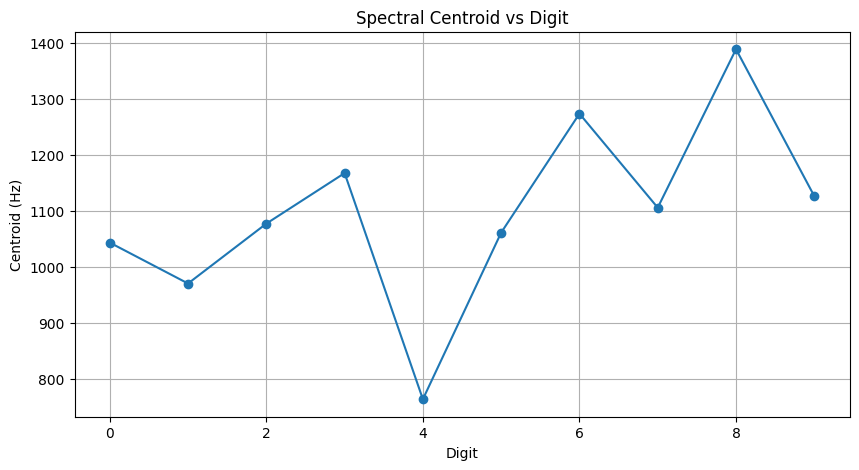

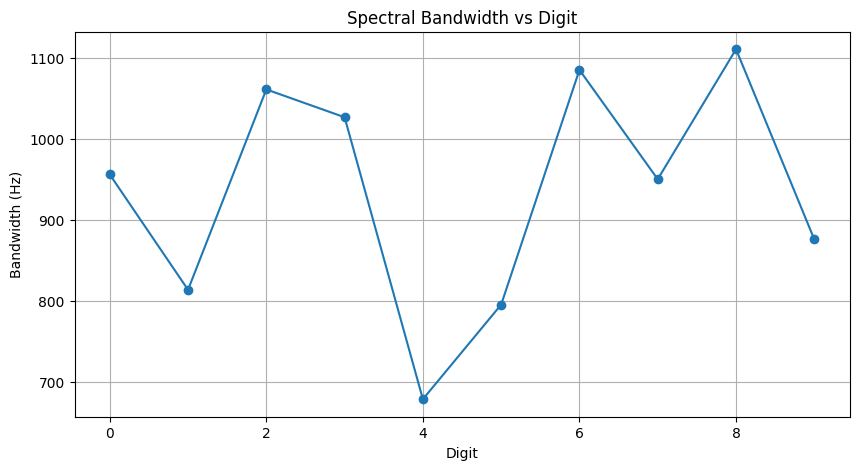

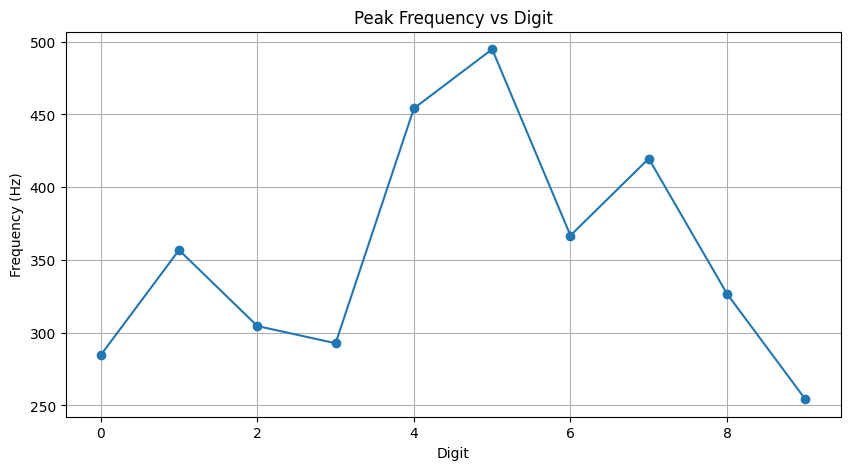

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(digit_summary.index, digit_summary["spectral_centroid"], marker='o')
plt.title("Spectral Centroid vs Digit")
plt.xlabel("Digit")
plt.ylabel("Centroid (Hz)")
plt.grid()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(digit_summary.index, digit_summary["spectral_bandwidth"], marker='o')
plt.title("Spectral Bandwidth vs Digit")
plt.xlabel("Digit")
plt.ylabel("Bandwidth (Hz)")
plt.grid()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(digit_summary.index, digit_summary["peak_frequency"], marker='o')
plt.title("Peak Frequency vs Digit")
plt.xlabel("Digit")
plt.ylabel("Frequency (Hz)")
plt.grid()
plt.show()



In [44]:
def spectral_leakage_only(signal, sample_rate):
    N = len(signal)

    freqs = np.fft.rfftfreq(N, d=1/sample_rate)
    magnitude = np.abs(np.fft.rfft(signal))

    plt.figure(figsize=(10,4))
    plt.plot(freqs, magnitude)
    plt.title("Spectral Leakage (No Window)")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.grid()
    plt.show()

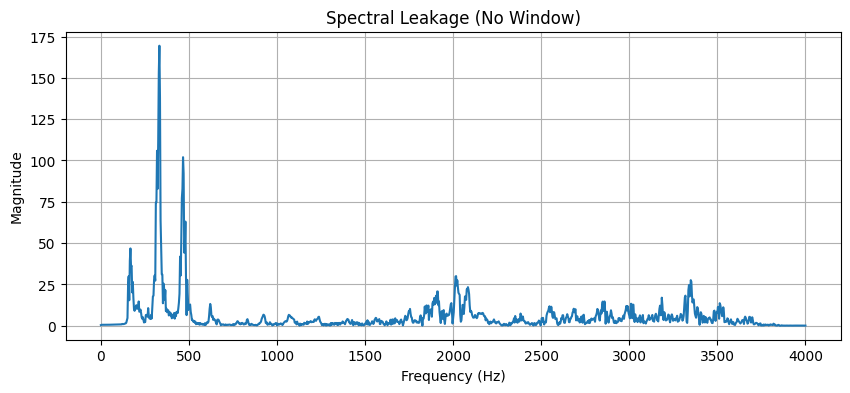

In [45]:
spectral_leakage_only(signal, sample_rate)

In [46]:
def windowing_effect(signal, sample_rate):
    N = len(signal)

    freqs = np.fft.rfftfreq(N, d=1/sample_rate)

    # Original
    mag_original = np.abs(np.fft.rfft(signal))

    # Apply window
    window = np.hamming(N)
    signal_windowed = signal * window
    mag_windowed = np.abs(np.fft.rfft(signal_windowed))

    plt.figure(figsize=(10,4))
    plt.plot(freqs, mag_original, label="No Window")
    plt.plot(freqs, mag_windowed, label="Hamming Window", alpha=0.7)
    plt.legend()
    plt.title("Effect of Windowing")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.grid()
    plt.show()

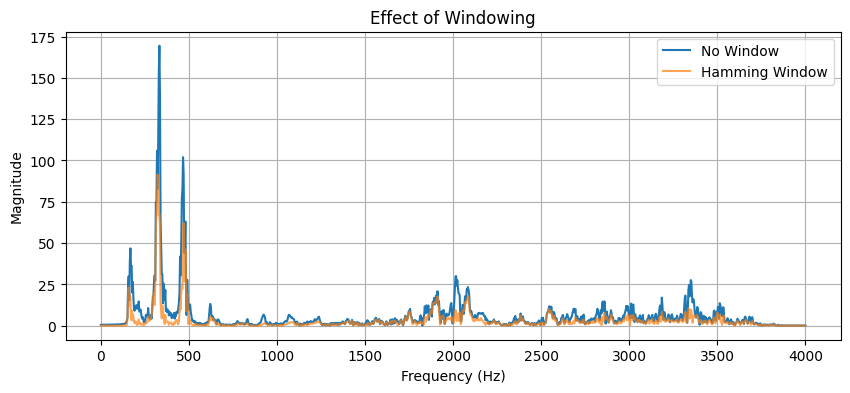

In [47]:
windowing_effect(signal, sample_rate)

In [48]:
import numpy as np
import pandas as pd
import os
import librosa
from scipy.signal import find_peaks
from scipy.linalg import toeplitz, solve_toeplitz

In [49]:
# =========================
# 1. MFCC Features
# =========================

def mfcc_features(signal, sample_rate, n_mfcc=13):
    """
    Extract MFCC features and return their mean values.
    """
    mfcc = librosa.feature.mfcc(y=signal, sr=sample_rate, n_mfcc=n_mfcc)
    mfcc_mean = np.mean(mfcc, axis=1)
    return mfcc_mean

In [50]:
# =========================
# 2. Formant Frequencies
# =========================

def formant_frequencies(signal, sample_rate, num_formants=3):
    """
    Estimate formant frequencies using LPC.
    Returns the first few formant frequencies.
    """
    signal = signal + 1e-8

    # Pre-emphasis
    emphasized = np.append(signal[0], signal[1:] - 0.97 * signal[:-1])

    # LPC order
    order = 2 + sample_rate // 1000

    # Autocorrelation
    autocorr = np.correlate(emphasized, emphasized, mode="full")
    autocorr = autocorr[len(autocorr)//2:]

    if len(autocorr) <= order:
        return [0.0] * num_formants

    r = autocorr[:order + 1]

    try:
        a = solve_toeplitz((r[:-1], r[:-1]), -r[1:])
        lpc_coeffs = np.concatenate(([1], a))
    except:
        return [0.0] * num_formants

    roots = np.roots(lpc_coeffs)
    roots = [r for r in roots if np.imag(r) >= 0]

    angles = np.angle(roots)
    freqs = angles * sample_rate / (2 * np.pi)

    freqs = sorted([f for f in freqs if 90 < f < sample_rate / 2])

    while len(freqs) < num_formants:
        freqs.append(0.0)

    return freqs[:num_formants]

In [51]:
# =========================
# 3. Harmonic-to-Noise Ratio
# =========================

def harmonic_to_noise_ratio(signal):
    """
    Estimate Harmonic-to-Noise Ratio using autocorrelation.
    """
    signal = signal - np.mean(signal)

    autocorr = np.correlate(signal, signal, mode="full")
    autocorr = autocorr[len(autocorr)//2:]

    if autocorr[0] == 0:
        return 0.0

    autocorr = autocorr / autocorr[0]

    peaks, _ = find_peaks(autocorr, distance=20)

    if len(peaks) == 0:
        return 0.0

    peak_value = autocorr[peaks[0]]

    if peak_value <= 0 or peak_value >= 1:
        return 0.0

    hnr = 10 * np.log10(peak_value / (1 - peak_value))
    return hnr

In [52]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

def mfcc_demo(file_path):
    signal, sample_rate = librosa.load(file_path, sr=None)

    mfcc = librosa.feature.mfcc(y=signal, sr=sample_rate, n_mfcc=13)

    print("MFCC shape:", mfcc.shape)

    plt.figure(figsize=(10,4))
    plt.imshow(mfcc, aspect='auto', origin='lower')
    plt.title("MFCC Features")
    plt.xlabel("Time Frames")
    plt.ylabel("MFCC Coefficients")
    plt.colorbar()
    plt.show()

MFCC shape: (13, 5)


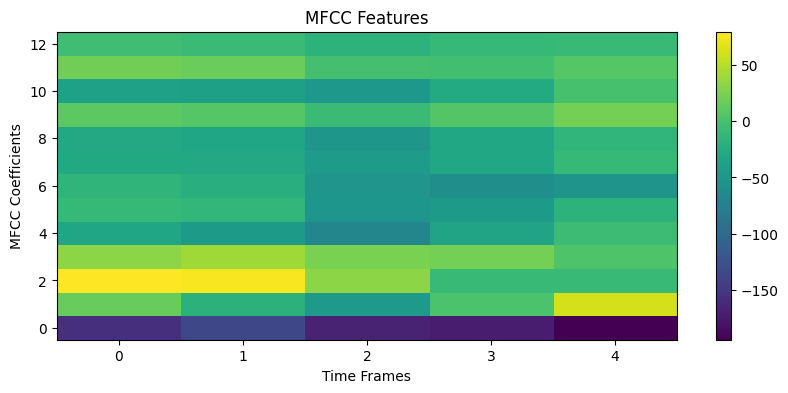

In [53]:
mfcc_demo(file_path)

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter


def formant_demo_lpc(signal, sample_rate, num_formants=3):



    signal = signal - np.mean(signal)


    emphasized = lfilter([1, -0.97], [1], signal)


    emphasized = emphasized * np.hamming(len(emphasized))


    order = int(sample_rate / 1000) + 2


    autocorr = np.correlate(emphasized, emphasized, mode="full")
    autocorr = autocorr[len(autocorr)//2:]

    R = autocorr[:order + 1]

    if R[0] == 0:
        print("Unable to estimate formants.")
        return []


    A = np.empty((order, order))

    for i in range(order):
        for j in range(order):
            A[i, j] = R[abs(i - j)]

    b = -R[1:order + 1]

    try:
        lpc_coeffs = np.linalg.solve(A, b)
    except np.linalg.LinAlgError:
        print("LPC solving failed.")
        return []

    lpc_coeffs = np.concatenate(([1], lpc_coeffs))


    roots = np.roots(lpc_coeffs)


    roots = [r for r in roots if np.imag(r) >= 0.01]


    angles = np.angle(roots)
    formants = sorted(angles * sample_rate / (2 * np.pi))


    formants = [f for f in formants if 200 < f < 3500]


    formants = formants[:num_formants]

    print("Estimated Formants (Hz):", formants)


    freqs = np.fft.rfftfreq(len(signal), d=1/sample_rate)
    magnitude = np.abs(np.fft.rfft(signal))

    plt.figure(figsize=(10,4))
    plt.plot(freqs, magnitude)

    for f in formants:
        plt.axvline(f, color="red", linestyle="--", label=f"{f:.1f} Hz")

    plt.title("Estimated Formant Frequencies using LPC")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.grid()
    plt.legend()
    plt.show()

    return formants

Estimated Formants (Hz): [np.float64(385.80643198047596), np.float64(1828.0864108764463), np.float64(1964.3224719674072)]


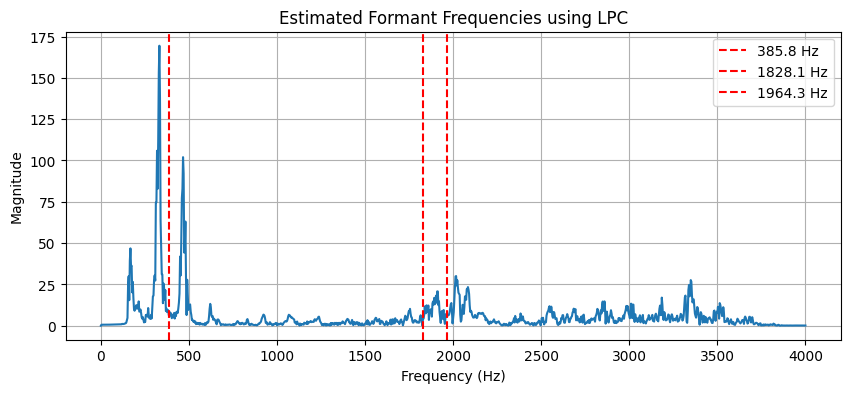

In [59]:
formants = formant_demo_lpc(signal, sample_rate)

In [56]:
def hnr_demo(signal):
    signal = signal - np.mean(signal)

    autocorr = np.correlate(signal, signal, mode='full')
    autocorr = autocorr[len(autocorr)//2:]

    autocorr = autocorr / autocorr[0]

    peak = np.max(autocorr[1:])

    if peak <= 0 or peak >= 1:
        hnr = 0
    else:
        hnr = 10 * np.log10(peak / (1 - peak))

    print("HNR (dB):", hnr)

In [57]:
hnr_demo(signal)

HNR (dB): 4.787158737804146
